In [73]:
!pip install ucimlrepo

# Task 1: Dataset Exploration


In [74]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
banknote_authentication = fetch_ucirepo(id=267)

# data (as pandas dataframes)
X = banknote_authentication.data.features
y = banknote_authentication.data.targets


In [75]:
# print first 5 rows
print(X.head())

   variance  skewness  curtosis  entropy
0   3.62160    8.6661   -2.8073 -0.44699
1   4.54590    8.1674   -2.4586 -1.46210
2   3.86600   -2.6383    1.9242  0.10645
3   3.45660    9.5228   -4.0112 -3.59440
4   0.32924   -4.4552    4.5718 -0.98880


In [76]:
# print dimension of the dataset.
print(X.shape)

(1372, 4)


In [77]:
# find number of missing values
print(X.isna().sum())

variance    0
skewness    0
curtosis    0
entropy     0
dtype: int64


In [78]:
# display descriptive statistics
print(X.describe())

          variance     skewness     curtosis      entropy
count  1372.000000  1372.000000  1372.000000  1372.000000
mean      0.433735     1.922353     1.397627    -1.191657
std       2.842763     5.869047     4.310030     2.101013
min      -7.042100   -13.773100    -5.286100    -8.548200
25%      -1.773000    -1.708200    -1.574975    -2.413450
50%       0.496180     2.319650     0.616630    -0.586650
75%       2.821475     6.814625     3.179250     0.394810
max       6.824800    12.951600    17.927400     2.449500


# Task 2: Exploratory Data Analysis

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Combine X and y for easier plotting
# Assuming y is named 'class' or similar, let's explicitly name it
df = pd.DataFrame(X)
df['target'] = y.values.ravel()

# Global styling for crisp, bold academic plots
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

In [80]:
# Histogram

plt.figure(figsize=(12, 8))
features = X.columns
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, hue='target', kde=True, element='step', palette='Set1')
    plt.xlabel(col, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    if plt.gca().get_legend():
        plt.setp(plt.gca().get_legend().get_texts(), fontweight='bold')

plt.tight_layout()
plt.savefig('eda_histograms.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

In [81]:
# Correlation heatmap

plt.figure(figsize=(8, 6))
# Calculate correlation on features only
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            annot_kws={'weight': 'bold'}, cbar_kws={'label': 'Correlation Coefficient'})

# Bold the axis ticks
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
# Bold the colorbar label
cbar = plt.gca().collections[0].colorbar
cbar.ax.set_ylabel('Correlation Coefficient', fontweight='bold')
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.savefig('eda_heatmap.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

/tmp/ipykernel_1697/427256977.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), fontweight='bold')


In [82]:
# Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=features[0], y=features[1], hue='target', palette='Set1', alpha=0.8)
plt.xlabel(features[0], fontweight='bold')
plt.ylabel(features[1], fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(title='Class', prop={'weight':'bold'})

plt.tight_layout()
plt.savefig('eda_scatterplot.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

In [83]:
# Boxplot

plt.figure(figsize=(12, 8))
df_melted = pd.melt(df, id_vars=['target'], value_vars=features,
                    var_name='Feature', value_name='Value')

ax = sns.boxplot(data=df_melted, x='Feature', y='Value', hue='target', palette='Set2')
plt.xlabel('Features', fontweight='bold')
plt.ylabel('Value Range', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(title='Class', prop={'weight':'bold'})

plt.tight_layout()
plt.savefig('eda_boxplots.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

# Task 3: Data Preprocessing

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to a DataFrame to preserve structure
X_normalized = pd.DataFrame(X_scaled, columns=X.columns)

# Split the dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1097, 4)
Testing set shape: (275, 4)


# Task 4: Perceptron Implementation

In [85]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=10):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def initialize_parameters(self, n_features):
        # Initialize weights to small random values and bias to zero
        np.random.seed(42)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0

    def activation_function(self, z):
        # Step activation function
        return np.where(z >= 0, 1, 0)

    def forward(self, X):
        # Linear combination followed by step activation
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_function(linear_output)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.initialize_parameters(n_features)
        y_true = np.array(y).ravel()

        print(f"{'Epoch':<8}{'Misclassified':<18}{'Updated Weights':<45}{'Updated Bias':<12}")
        print("-" * 85)

        for epoch in range(1, self.epochs + 1):
            misclassified_count = 0

            # First pass to count misclassifications before this epoch's updates
            current_preds = self.forward(X)
            misclassified_count = np.sum(current_preds != y_true)

            # Iterate through every sample to apply the learning rule
            for idx in range(n_samples):
                y_pred = self.forward(X[idx])
                error = y_true[idx] - y_pred

                # Update parameters if a misclassification occurs
                if error != 0:
                    self.weights += self.lr * error * X[idx]
                    self.bias += self.lr * error

            # Format weights for clean tabular printing
            weights_str = np.array2string(self.weights, precision=4, separator=', ')
            print(f"{epoch:<8}{misclassified_count:<18}{weights_str:<45}{self.bias:<12.4f}")

    def predict(self, X):
        # Public method to generate final predictions for new data
        return self.forward(X)

X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy()

# Task 5: Model Training

In [86]:
# Evaluate performance on the testing subset
model = Perceptron(learning_rate=0.01, epochs=20)
model.fit(X_train_np, y_train_np)

Epoch   Misclassified     Updated Weights                              Updated Bias
-------------------------------------------------------------------------------------
1       586               [-0.0623, -0.0697, -0.065 , -0.0025]         -0.0300     
2       9                 [-0.0851, -0.086 , -0.0769,  0.0013]         -0.0500     
3       17                [-0.1048, -0.1132, -0.0794,  0.002 ]         -0.0400     
4       22                [-0.095 , -0.1159, -0.1015,  0.0081]         -0.0600     
5       19                [-0.1032, -0.1403, -0.1065,  0.0074]         -0.0400     
6       21                [-0.1115, -0.1438, -0.1026,  0.0005]         -0.0600     
7       21                [-0.1162, -0.1511, -0.1123,  0.0083]         -0.0600     
8       21                [-0.1106, -0.1509, -0.131 ,  0.0024]         -0.0700     
9       17                [-0.1307, -0.1569, -0.123 , -0.0072]         -0.0600     
10      14                [-0.1285, -0.1643, -0.134 , -0.0084]         -0.

# Task 6: Model Evaluation


In [87]:
import numpy as np

# 1. Generate predictions on the test dataset
X_test_np = X_test.to_numpy()
y_test_np = y_test.to_numpy().ravel()
y_pred_np = model.forward(X_test_np)

# 2. Calculate True Positives, True Negatives, False Positives, False Negatives
tp = np.sum((y_test_np == 1) & (y_pred_np == 1))
tn = np.sum((y_test_np == 0) & (y_pred_np == 0))
fp = np.sum((y_test_np == 0) & (y_pred_np == 1))
fn = np.sum((y_test_np == 1) & (y_pred_np == 0))

# 3. Compute evaluation metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# 4. Construct the Confusion Matrix array
confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

# 5. Display the performance results
print("--- MODEL EVALUATION METRICS ---")
print(f"Accuracy:  {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

--- MODEL EVALUATION METRICS ---
Accuracy:  98.18%
Precision: 0.9606
Recall:    1.0000
F1-Score:  0.9799


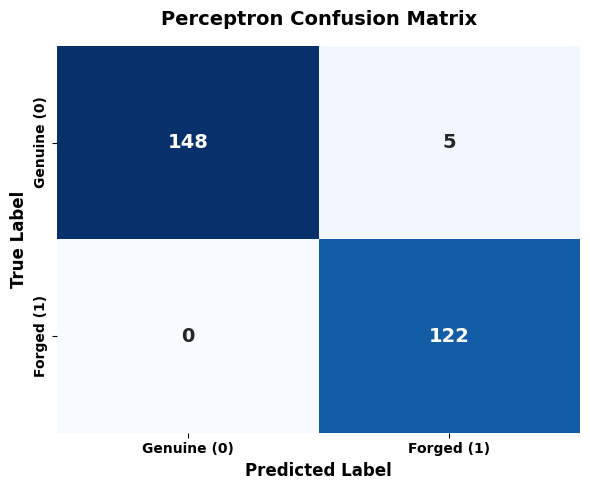

In [88]:
plt.figure(figsize=(6, 5))

# Create a heatmap using seaborn
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Genuine (0)', 'Forged (1)'],
            yticklabels=['Genuine (0)', 'Forged (1)'],
            annot_kws={'size': 14, 'weight': 'bold'})

# Add bold axis labels
plt.xlabel('Predicted Label', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold', fontsize=12)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.title('Perceptron Confusion Matrix', fontweight='bold', fontsize=14, pad=15)

# Display the final plot cleanly
plt.tight_layout()
plt.savefig('perceptron_confusion_matrix.eps', format='eps', dpi=600, bbox_inches='tight')

# Additional Plots

In [89]:
import numpy as np
import matplotlib.pyplot as plt

# Global styling for crisp academic plots
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# Convert data to numpy arrays
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().ravel()

# 1. TRACKING DATA FOR SINGLE RUN (Learning Rate = 0.01, 20 Epochs)

model = Perceptron(learning_rate=0.01, epochs=20)
n_samples, n_features = X_train_np.shape

# Initialize tracking lists
epoch_errors = []
weight_history = []
bias_history = []

# Manual training loop to extract historical parameters per epoch
model.initialize_parameters(n_features)
for epoch in range(1, model.epochs + 1):
    # Track initial error before this epoch's updates
    current_preds = model.forward(X_train_np)
    misclassified = np.sum(current_preds != y_train_np)
    epoch_errors.append(misclassified)

    # Save weight and bias states
    weight_history.append(model.weights.copy())
    bias_history.append(model.bias)

    for idx in range(n_samples):
        y_pred = model.forward(X_train_np[idx])
        error = y_train_np[idx] - y_pred
        if error != 0:
            model.weights += model.lr * error * X_train_np[idx]
            model.bias += model.lr * error

weight_history = np.array(weight_history)

# Plot 1: Training Error vs Epoch
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(epoch_errors) + 1), epoch_errors, marker='o', color='crimson', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Misclassified Samples', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('perceptron_error_vs_epoch.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

# Plot 2: Weight Evolution
plt.figure(figsize=(6, 4))
for i in range(n_features):
    plt.plot(range(1, len(weight_history) + 1), weight_history[:, i], marker='s', label=f'w_{i+1}', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Weight Value', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(prop={'weight':'bold'})
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('perceptron_weight_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

# Plot 3: Bias Evolution
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(bias_history) + 1), bias_history, marker='^', color='darkorange', linewidth=2)
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Bias Value', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('perceptron_bias_evolution.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()


# 2. LEARNING RATE COMPARISON
learning_rates = [0.1, 0.01, 0.001, 0.0001]
plt.figure(figsize=(7, 5))

for lr in learning_rates:
    comp_model = Perceptron(learning_rate=lr, epochs=20)
    comp_model.initialize_parameters(n_features)
    lr_errors = []

    for epoch in range(comp_model.epochs):
        preds = comp_model.forward(X_train_np)
        lr_errors.append(np.sum(preds != y_train_np))

        for idx in range(n_samples):
            pred = comp_model.forward(X_train_np[idx])
            err = y_train_np[idx] - pred
            if err != 0:
                comp_model.weights += comp_model.lr * err * X_train_np[idx]
                comp_model.bias += comp_model.lr * err

    plt.plot(range(1, comp_model.epochs + 1), lr_errors, marker='o', label=f'eta = {lr}', linewidth=2)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Misclassified Samples', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(title='Learning Rates', prop={'weight':'bold'})
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('perceptron_lr_comparison.eps', format='eps', dpi=600, bbox_inches='tight')
plt.close()

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Global styling for crisp academic plots
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

def plot_decision_boundary(X, y, model, x_index=0, y_index=2, filename='decision_boundary.eps'):
    """
    Plots the decision boundary for a Perceptron model based on two specified features.

    Args:
        X (np.ndarray): The normalized training feature data.
        y (np.ndarray): The training target data.
        model (Perceptron): The trained Perceptron model object.
        x_index (int): Index of the feature for the x-axis (e.g., Variance=0).
        y_index (int): Index of the feature for the y-axis (e.g., Curtosis=2).
        filename (str): Name of the EPS file to save.
    """
    # Extract the two features and the targets
    X_plot = X[:, [x_index, y_index]]
    y_plot = y.ravel()

    # Configure plot size
    plt.figure(figsize=(7, 6))

    # Identify class indices
    genuine_indices = np.where(y_plot == 0)[0]
    forged_indices = np.where(y_plot == 1)[0]

    # Scatter plot of the data points, coloring by class
    plt.scatter(X_plot[genuine_indices, 0], X_plot[genuine_indices, 1],
                color='skyblue', label='Genuine (0)', alpha=0.7, edgecolor='k', marker='o')
    plt.scatter(X_plot[forged_indices, 0], X_plot[forged_indices, 1],
                color='salmon', label='Forged (1)', alpha=0.7, edgecolor='k', marker='^')

    # Generate a mesh grid of points covering the feature space
    x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
    y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Reconstruct the mesh grid points into the full feature dimension
    # required by the model (filling unused features with zeros)
    num_samples_grid = xx.ravel().shape[0]
    num_features_total = X.shape[1]
    full_grid_data = np.zeros((num_samples_grid, num_features_total))
    full_grid_data[:, x_index] = xx.ravel()
    full_grid_data[:, y_index] = yy.ravel()

    # Get predictions for the full mesh grid
    Z = model.predict(full_grid_data)
    Z = Z.reshape(xx.shape)

    # Plot the decision region boundaries
    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')

    # Extract and plot the explicit decision boundary line (where linear_output = 0)
    # Equation: x*w_x + y*w_y + b = 0 => y = -(x*w_x + b) / w_y
    w_x = model.weights[x_index]
    w_y = model.weights[y_index]
    b = model.bias

    # Prevent division by zero if w_y is negligible
    if np.abs(w_y) > 1e-9:
        boundary_x = np.array([x_min, x_max])
        boundary_y = -(boundary_x * w_x + b) / w_y
        plt.plot(boundary_x, boundary_y, color='black', linestyle='--', linewidth=2, label='Decision Boundary')

    # Set labels with bold styling
    plt.xlabel('Variance (Normalized)', fontweight='bold', fontsize=12)
    plt.ylabel('Curtosis (Normalized)', fontweight='bold', fontsize=12)
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.title('Perceptron Decision Boundary: Variance vs. Curtosis', fontweight='bold', fontsize=14, pad=15)
    plt.legend(frameon=True, fontsize=10, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Display the plot
    plt.tight_layout()

    # Save the plot as an EPS file
    plt.savefig(filename, format='eps', dpi=600, bbox_inches='tight')
    plt.close()

# ----------------------------------------------------------------
# Execute the Plotting Function
# ----------------------------------------------------------------
# Convert data to numpy arrays (ensure these were generated previously)
X_train_np = X_train.to_numpy()
y_train_np = y_train.to_numpy().ravel()

# Make sure the model 'model' is trained and available before running this.
# For example, assume it is 'model = Perceptron(learning_rate=0.01, epochs=20)' from previous steps.

# Pass indices: Variance (column 0) vs. Curtosis (column 2)
plot_decision_boundary(X_train_np, y_train_np, model, x_index=0, y_index=2, filename='perceptron_variance_curtosis_boundary.eps')

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. Step vs Sigmoid Activation Plot (For Question 1)

# Define the step function
def step_function(z): return np.where(z >= 0, 1, 0)

# Define the sigmoid function
def sigmoid_function(z): return 1 / (1 + np.exp(-z))

# Generate continuous z values for smooth plotting
z = np.linspace(-10, 10, 100)

# Plot both functions for visual comparison
plt.figure(figsize=(6, 4))
plt.plot(z, step_function(z), label='Step Function', linewidth=2, color='blue')
plt.plot(z, sigmoid_function(z), label='Sigmoid Function', linewidth=2, color='red')
plt.xlabel('z', fontweight='bold')
plt.ylabel('Activation', fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend(prop={'weight': 'bold'})
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('activation_comparison.eps', format='eps', dpi=600)
plt.close()

# 2. Scikit-Learn Perceptron Comparison (For Question 2)
# Initialize Scikit-Learn Perceptron with identical hyperparameters
sk_model = SklearnPerceptron(eta0=0.01, max_iter=20, random_state=42)

# Train the sklearn model
sk_model.fit(X_train_np, y_train_np.ravel())

# Predict and calculate accuracy
sk_preds = sk_model.predict(X_test_np)
sk_accuracy = accuracy_score(y_test_np.ravel(), sk_preds)

# Extract and format sklearn parameters for report table
sk_weights = np.array2string(sk_model.coef_[0], precision=4, separator=', ')
sk_bias = sk_model.intercept_[0]
print(f"Scikit-Learn Accuracy: {sk_accuracy * 100:.2f}%")
print(f"Scikit-Learn Weights:  {sk_weights}")
print(f"Scikit-Learn Bias:     {sk_bias:.4f}")

# 3. Learning Rate Accuracies (For Question 3)
# Note: You already have the plot, this just prints the raw numbers
for lr in [0.001, 0.01, 0.1]:
    lr_model = Perceptron(learning_rate=lr, epochs=20)
    lr_model.fit(X_train_np, y_train_np.ravel())
    lr_acc = np.mean(lr_model.predict(X_test_np) == y_test_np.ravel())
    print(f"Custom Perceptron (LR={lr}): Test Accuracy = {lr_acc * 100:.2f}%")

# 4. XOR Problem Failure Proof (For Question 4)
# Create standard non-linear XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Train custom perceptron on XOR data
xor_model = Perceptron(learning_rate=0.1, epochs=20)
xor_model.fit(X_xor, y_xor)

# Generate predictions to prove it fails
xor_preds = xor_model.predict(X_xor)
print(f"XOR True Labels:   {y_xor}")
print(f"XOR Predicted:     {xor_preds}")

# 5. Unnormalized Data Comparison (For Question 5)
# Extract the original unscaled data directly from the fetch_ucirepo object
X_unscaled = banknote_authentication.data.features

# Split unscaled data exactly like the scaled data
X_train_unscaled, X_test_unscaled, _, _ = train_test_split(
    X_unscaled, y, test_size=0.20, random_state=42, stratify=y
)

# Convert to numpy arrays
X_train_unscaled_np = X_train_unscaled.to_numpy()
X_test_unscaled_np = X_test_unscaled.to_numpy()

# Train a new model on unnormalized data
unnorm_model = Perceptron(learning_rate=0.01, epochs=20)
unnorm_model.fit(X_train_unscaled_np, y_train_np.ravel())

# Evaluate performance on unnormalized test set
unnorm_preds = unnorm_model.predict(X_test_unscaled_np)
unnorm_acc = np.mean(unnorm_preds == y_test_np.ravel())
print(f"Unnormalized Data Test Accuracy: {unnorm_acc * 100:.2f}%")

Scikit-Learn Accuracy: 97.45%
Scikit-Learn Weights:  [-0.1169, -0.1422, -0.1107,  0.005 ]
Scikit-Learn Bias:     -0.0300
Epoch   Misclassified     Updated Weights                              Updated Bias
-------------------------------------------------------------------------------------
1       586               [-0.0057, -0.0079, -0.0056, -0.0001]         -0.0030     
2       17                [-0.007 , -0.0085, -0.0073,  0.0008]         -0.0030     
3       14                [-0.0075, -0.0111, -0.0072,  0.0011]         -0.0040     
4       50                [-0.0081, -0.0112, -0.0101,  0.0003]         -0.0050     
5       20                [-0.0093, -0.0124, -0.0109, -0.0002]         -0.0050     
6       9                 [-0.0102, -0.0139, -0.0112,  0.0008]         -0.0060     
7       14                [-0.0108, -0.0135, -0.0122, -0.0005]         -0.0070     
8       16                [-0.0107, -0.015 , -0.0129,  0.0001]         -0.0070     
9       18                [-0.0123, -